# 20.3.2026 - Initial Exploration of Data and First Try of Analysis

Mainly written by Sarah-Rose and Marie

In [2]:

## Importing Packages

## Importing Datascience Packages
import numpy as np
import geopandas as gpd
import pandas as pd
import json

## Importing Climada
from climada.util.api_client import Client
import climada.util.lines_polys_handler as u_lp
from climada.entity.impact_funcs import ImpactFuncSet
from climada.entity.impact_funcs.storm_europe import ImpfStormEurope
from climada.entity import Exposures
from climada.entity import ImpactFunc
from climada.engine import ImpactCalc

In [2]:
## Defining Path to Data Folder
data_path = "../data/"

## Importing Data

In [10]:
from shapely.geometry import shape

# import departement boundaries
df = pd.read_csv(data_path + "geo-contours-departements.csv")
df = df.dropna(subset=["geometry"])
df["geometry"] = df["geometry"].apply(lambda x: shape(json.loads(x)))

gdf = gpd.GeoDataFrame(df, geometry="geometry")

gdf

,geometry,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB
0,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...",01,Ain,Auvergne-Rhône-Alpes
1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ...",02,Aisne,Hauts-de-France
2,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ...",03,Allier,Auvergne-Rhône-Alpes
3,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6...",04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur
4,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ...",05,Hautes-Alpes,Provence-Alpes-Côte d'Azur
...,...,...,...,...
103,"MULTIPOLYGON (((-63.04517 18.11916, -63.04512 ...",978,Saint-Martin,NaN
105,"MULTIPOLYGON (((-176.20473 -13.1875, -176.2038...",986,Wallis et Futuna,NaN
106,"MULTIPOLYGON (((-147.15703 -15.17802, -147.204...",987,Polynésie française,NaN
107,"MULTIPOLYGON (((167.0236 -22.27614, 167.02279 ...",988,Nouvelle-Calédonie,NaN


In [11]:
# import crop data per departement
crop_df = pd.read_excel(data_path +"crop_data_france.xlsx",skiprows=2)

# Rename to obtain a key to merge
crop_df = crop_df.rename(columns={"Numéro de département": "DDEP_C_COD"})

crop_df

,DDEP_C_COD,Libellé de département,Part des grandes cultures dans la superficie du département \n(en %)
0,01,Ain,19.9
1,02,Aisne,53.2
2,03,Allier,17
3,04,Alpes-de-Haute-Provence,2.5
4,05,Hautes-Alpes,1.7
...,...,...,...
95,95,Val-d'Oise,38.1
96,s : résultat couvert par le secret statistique.,NaN,NaN
97,Lecture : Les grandes cultures sont principale...,NaN,NaN
98,Champ : France métropolitaine.,NaN,NaN


## Raw Data -> Exposure Object

In [12]:
# Merge with Geometry + Data
gdf = gdf.merge(crop_df.iloc[:, [0, 2]], on="DDEP_C_COD")

In [13]:

## Process Data for CLIMADA

# Rename to obtain a key to merge
gdf = gdf.rename(columns={"Part des grandes cultures dans la superficie du département \n(en %)": "value"})

gdf["value"] = gdf["value"].replace("s", np.nan) # remove lines with value = "S" --> secret statistique mdr

# add impact function column in exposure data
gdf["impf_WS"] = 1

# create Exposure object out of dataframe
exp_poly=Exposures(gdf)   

In [14]:
print(gdf.columns)

Index(['geometry', 'DDEP_C_COD', 'DDEP_L_LIB', 'DREG_L_LIB', 'value',
       'impf_WS'],
      dtype='object')


In [16]:
exp_poly.value

array([19.9, 53.2, 17. ,  2.5,  1.7,  0. ,  1.6, 29.2,  5.9, 50.3, 10.8,
        7.5,  6.1, 28.5,  1.8, 29.7, 39.2, 37.6,  2.1, 29.4, 27.2,  7.1,
        9.8,  4.5, 10.2, 47.5, 68. , 21.7,  0. ,  0.3,  3.8, 32.4, 47.2,
        4.3,  2.7, 22.9, 36.1, 37. , 12. ,  9.8, 14.4, 33.2,  5.3,  7.3,
       14.8, 42.4,  5.6, 31. ,  3. , 24.7, 11.7, 54.6, 26.7, 24. , 28.7,
       32.6, 22.1, 25.6, 18.8, 38.6, 51.9, 24.4, 47.3, 11.2, 14.7, 11.3,
        0.4, 24.6, 24.2,  8.9, 17.3, 13. , 31.1,  1.2,  2.6,  0. , 38. ,
       51. , 32.3, 40. , 60.3, 23.4, 29.6,  0.7,  3.7, 29.5, 44.4,  7.8,
        8.4, 41. , 11.1, 40.3,  nan,  nan,  2.9, 38.1])

In [17]:

# Disaggregate exposure to 0.1° grid (~11km), no value disaggregation specified --> replicate initial value
exp_raster = u_lp.exp_geom_to_pnt(
    exp=exp_poly,
    res=0.05,
    to_meters=False,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

## Defining Hazard

In [18]:
# HAZARD: STORM EUROPE

client = Client()
ISO = "FRA"
hazard = client.get_hazard("storm_europe", properties={"country_iso3alpha": ISO})

/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


<GeoAxes: title={'center': 'Event ID 100: 100'}>

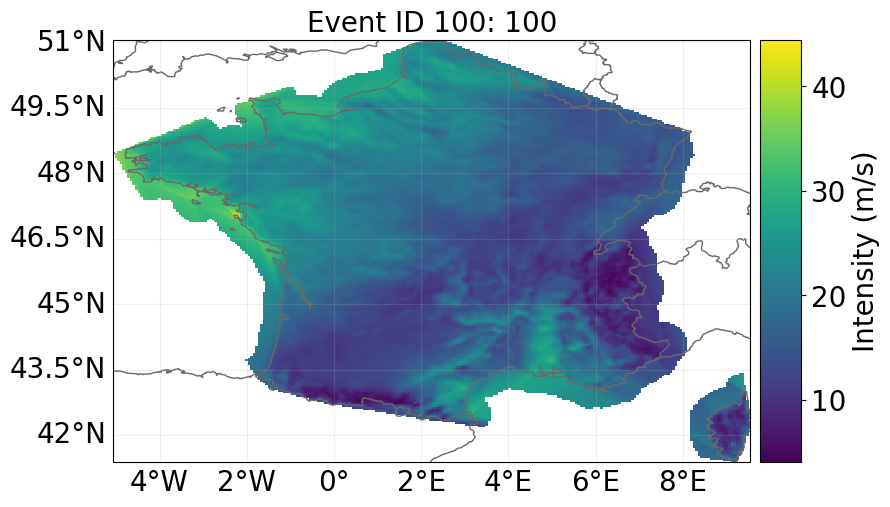

In [20]:
hazard.plot_intensity(event=100)

## Computing Impact

In [42]:
# IMPACT FUNCTION
impf_storm = ImpactFunc(
    id=1,
    name = "Storm Impact Function",
    intensity_unit="m/s",
    haz_type=hazard.haz_type,
    intensity=np.array([0, 12.1, 14.8, 16.8, 22]),
    mdd=np.array([0.0, 0.2, 0.4, 0.8, 1.0]),
    paa = np.ones(5)
)

impf_storm.check()

<Axes: title={'center': 'WS 1: Storm Impact Function'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>

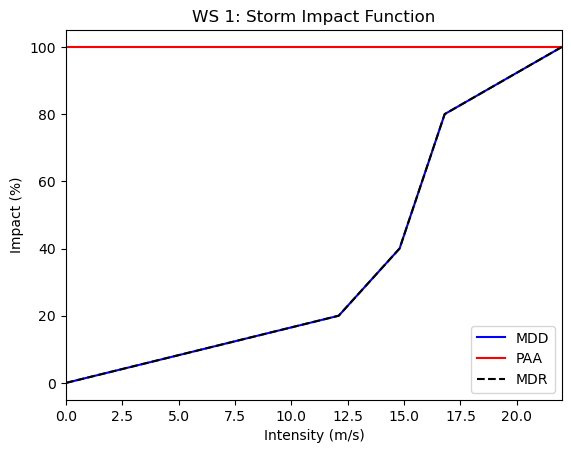

In [43]:
impf_storm.plot()

In [46]:
impf_fun_set = ImpactFuncSet([impf_storm])

In [47]:
# COMPUTING IMPACT
impactcalc = ImpactCalc(exposures=exp_raster, impfset=impf_fun_set, hazard=hazard)
impact = impactcalc.impact()

# impact.plot_raster_eai_exposure()

2026-03-20 14:31:43,425 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.078125 degree for 3 coordinates.


/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


<GeoAxes: title={'center': 'Expected annual impact'}>

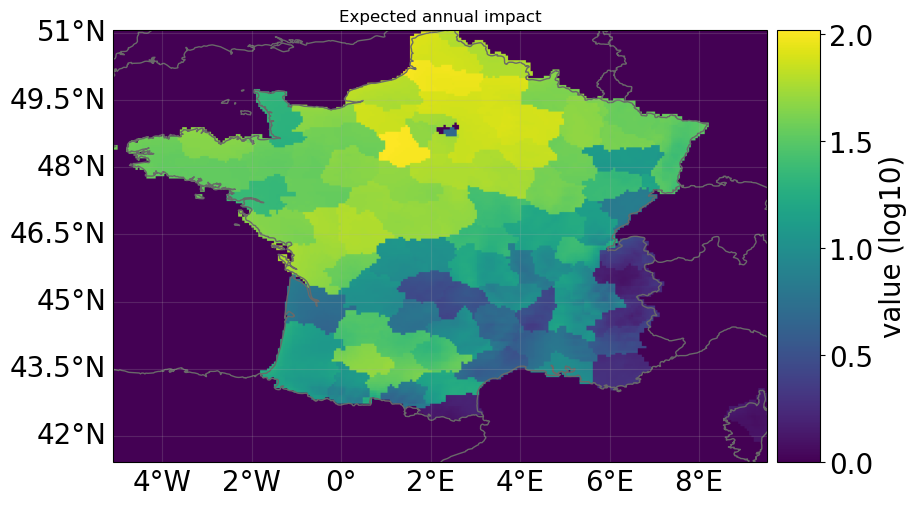

In [48]:
impact.plot_raster_eai_exposure()